# Course NIGK21007U - Integrated Water Resources Modelling
## Tutorial 4

This notebook shows you how to visualize and analyze results from the Mike SHE groundwater model you built in Tutorial 4 in python and work with the results creatively.

First, load all necessary packages:

In [1]:
import mikeio
from mikeio import Dfs3
import matplotlib.pyplot as plt
import geopandas as gpd

Define path and filename for the result file you want to analyze:

In [ ]:
my_file_name = r'h:\KU_Courses\NIGK21007U Integrated Water Resources Modelling\2026\Tutorials\Tutorial_4\Tutorial_4_model\Tutorial_4.she - Result Files\Tutorial_4_3DSZ.dfs3'

Open and inspect the file:

In [3]:
# Open the file to get a Dfs3 object (metadata is available but data isn't loaded yet)
dfs = Dfs3(my_file_name)

# Inspect file properties (e.g., number of time steps, items)
print(f"Number of time steps: {dfs.n_timesteps}")
print(f"Item names: {[item.name for item in dfs.items]}")

Number of time steps: 917
Item names: ['head elevation in saturated zone']


Define your item of interest:

In [ ]:
my_item = r'head elevation in saturated zone' # define the item you are interested in

Read the dataset:

In [5]:
# Read the Dataset (ds)
ds = mikeio.read(my_file_name, items=[my_item])
# extract the time indices from the file
time_array_datetime = ds.time.values
unit = repr(ds[my_item].unit) # get the unit - take not of the use of repr here - unit itself may be an internal code

# Get the DataArray for the item of interest
data_array = ds[my_item]
# The shape of the underlying data is (time, z, y, x)
print(data_array.shape) # Example output: (500, 10, 100, 80)

(917, 300, 270)


Make a time series plot in a selected model cell:

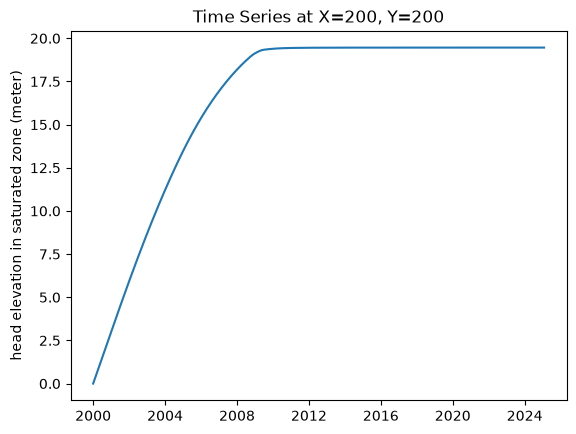

In [6]:
# Define the indices of the cell of interest
x_idx = 200
y_idx = 200

# Extract the time series using the indices (Time, Z, Y, X)
# The colon `:` for the time axis ensures we get ALL time steps.
time_series_values = data_array.values[:,  y_idx, x_idx]

fig, ax = plt.subplots()
ax.plot(time_array_datetime, time_series_values)
ax.set_ylabel(f"{my_item}" + ' (' + unit + ')')
ax.set_title(f"Time Series at X={x_idx}, Y={y_idx}")
plt.show()

Make a layer plot for a time of interest:

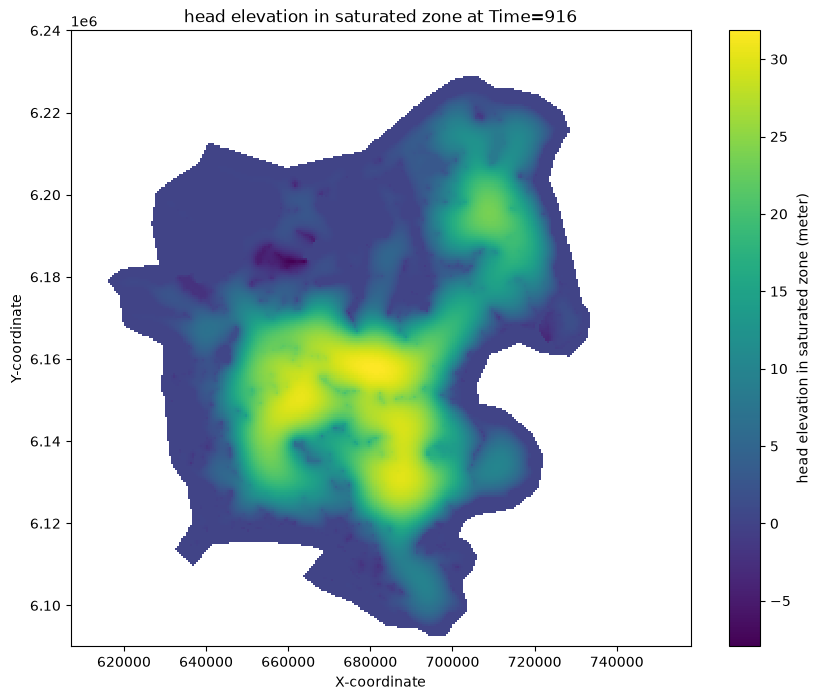

In [7]:
# Define the indices
t_idx = 916 # This is the selected time step
layer_values = data_array.values[t_idx, :, :]

# 1. Extract X and Y coordinates from the DataArray geometry
# For a rectilinear grid (DFS3), these are 1D arrays of center coordinates
x_coords = data_array.geometry.x
y_coords = data_array.geometry.y

# Assuming data_array, x_coords, y_coords, and layer_values are defined

fig, ax = plt.subplots(figsize=(10, 8))

# Use pcolormesh to create the colour plot
# Note: X and Y coordinates should be passed as 2D arrays (using np.meshgrid) 
# or pcolormesh will infer the corner points. We use the simpler method below.

# Plotting the data. We transpose the Y coordinates to match the (Y, X) data shape
c = ax.pcolormesh(x_coords, y_coords, layer_values, 
                  shading='auto', # Recommended for rectilinear grids
                  cmap='viridis')  # Choose a nice colour map (viridis, jet, coolwarm, etc.)

# Add a colour bar to show the scale
cbar = fig.colorbar(c, ax=ax)

# Clean up and label the plot
ax.set_title(f"{data_array.name} at Time={t_idx}")
ax.set_xlabel("X-coordinate")
ax.set_ylabel("Y-coordinate")

    
cbar.set_label(f"{my_item}" + ' (' + unit + ')')

plt.axis('equal') # Ensure the aspect ratio is correct for the map
plt.show()

Make a layer plot and overlay a shapefile:

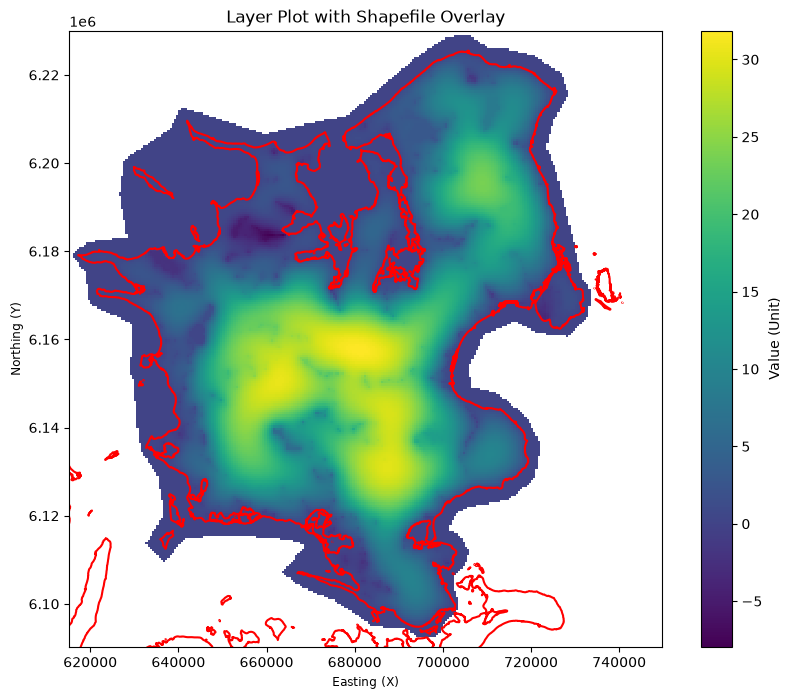

In [8]:
# 1. Read the Shapefile
# Replace 'path/to/your_shapefile.shp' with the actual path
shapefile_path = r'c:\Users\vpk410\Documents\DK1\MapsDK\DKDomains2013\kort10_land.shp'
gdf = gpd.read_file(shapefile_path)

fig, ax = plt.subplots(figsize=(10, 8))

# --- BASE LAYER (DFS3 Data) ---
# Use pcolormesh to create the colour plot
c = ax.pcolormesh(x_coords, y_coords, layer_values, 
                  shading='auto',
                  cmap='viridis',
                  zorder=1) # zorder=1 ensures it is plotted first

# Add color bar (optional but recommended)
cbar = fig.colorbar(c, ax=ax, label="Value (Unit)") # Update label as needed

# --- OVERLAY LAYER (Shapefile) ---
# Use GeoPandas plot method, passing the existing axes (ax)
gdf.plot(ax=ax, 
         edgecolor='red', # Color of the boundary line
         facecolor='none', # Make the interior transparent
         linewidth=1.5,
         zorder=2) # zorder=2 ensures it is plotted on top

# Determine the boundaries for the X-axis
min_x = x_coords.min()
max_x = x_coords.max()

# Determine the boundaries for the Y-axis
min_y = y_coords.min()
max_y = y_coords.max()

# Restrict X-axis limits using the min/max coordinates
ax.set_xlim(min_x, max_x)

# Restrict Y-axis limits using the min/max coordinates
ax.set_ylim(min_y, 6230000)

# Set Plot Aesthetics
ax.set_title(f"Layer Plot with Shapefile Overlay")
ax.set_xlabel("Easting (X)")
ax.set_ylabel("Northing (Y)")
# plt.axis('equal') # Maintain map aspect ratio
plt.show()